24 24
p 0.25


KeyboardInterrupt: 

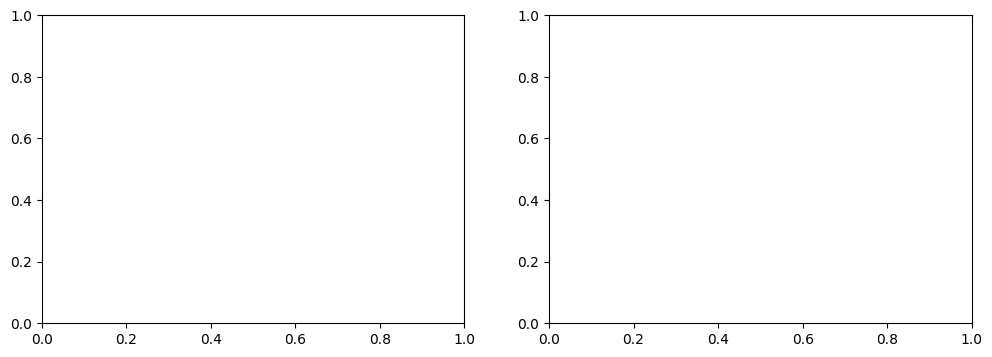

In [1]:
from __future__ import print_function, division
import sys,os
# line 4 and line 5 below are for development purposes and ca be removed
qspin_path = os.path.join(os.getcwd(),"../../")
sys.path.insert(0,qspin_path)
from quspin.operators import hamiltonian # Hamiltonians and operators
#from quspin.basis import spinless_fermion_basis_1d # Hilbert space fermion basis
from quspin.basis import spin_basis_1d # Hilbert space spin basis
import numpy as np # generic math functions
import matplotlib.pyplot as plt # plotting library
from scipy.linalg import expm, sinm, cosm
from numpy.linalg import multi_dot
from scipy.sparse import csr_matrix, csc_matrix, coo_matrix, lil_matrix
from scipy.sparse.linalg import inv, eigs
from scipy.linalg import svdvals
from scipy.stats import unitary_group
from scipy import linalg
from numpy import linalg as LA
import pylab
import time
import numba
from numba import njit,c16,i8,u2
import sys
import math

np.set_printoptions(precision=3)
np.set_printoptions(suppress=True)


####################
#cilyinder geometry#
####################

#################################################
def create_transformation_pv_link(Ld,Lx,Ly):
#############################################
############ plaquette part #################
#############################################
    #p_indd = np.zeros((Lx*Ly,4),dtype='uint32')
    p_indd=[]
    for ip in range(Lx*(Ly)):
        ix,iy = ip%Lx,ip//Lx
        if iy==0:
            p_indd+=[[ix+(Ld-Lx)+Ld,ix+Ld,ix+Lx+Ld,((ix+1)%Lx)+Ld]] #please check(9/6)
            #print(ip,ix+(Ld-Lx),ix,ix+Lx,((ix+1)%Lx)) 
        elif iy==Ly-1:
            p_indd+=[[ix+(Lx)+(2*Lx)*(iy-1)+Ld,ix+(Lx)+(2*Lx)*(iy-1)+Lx+Ld,ix+(Ld-Lx)+Ld,(ix+1)%Lx+(Lx)+(2*Lx)*(iy-1)+Lx+Ld]] #please check (9/6)
            #print(ip,ix+(Lx)+(2*Lx)*(iy-1),ix+(Lx)+(2*Lx)*(iy-1)+Lx,ix+(Ld-Lx),(ix+1)%Lx+(Lx)+(2*Lx)*(iy-1)+Lx)
        else:
            p_indd+=[[ix+(Lx)+(2*Lx)*(iy-1)+Ld,ix+(Lx)+(2*Lx)*(iy-1)+Lx+Ld,ix+(Lx)+(2*Lx)*(iy-1)+(2*Lx)+Ld,(ix+1)%Lx+(Lx)+(2*Lx)*(iy-1)+Lx+Ld]]       
            #print(ip,ix+(Lx)+(2*Lx)*(iy-1),ix+(Lx)+(2*Lx)*(iy-1)+Lx,ix+(Lx)+(2*Lx)*(iy-1)+(2*Lx),(ix+1)%Lx+(Lx)+(2*Lx)*(iy-1)+Lx)
    #sys.exit()
###########  Here, we add Ld to an index to simplify determining a binary representation
###########  In other words, Ld corresponds to the shift in a binary representation
###########  since plaquette parts are pauli Z operator

############################################
############ vertex part ###################
############################################
    #v_indd = np.zeros(((Lx+1)*(Ly-1),4),dtype='uint32')
    v_indd =[]
    for iv in range((Lx)*(Ly-1)):
        ix,iy = iv%(Lx),iv//(Lx)
        if ix==0:
            v_indd+=[[iy*(2*Lx),(iy+1)*(2*Lx)-1,(iy+1)*(2*Lx),iy*(2*Lx)+Lx]]
            #print(iv,iy*(2*Lx),(iy+1)*(2*Lx)-1,(iy+1)*(2*Lx),iy*(2*Lx)+Lx)
        elif ix==Lx-1:
            v_indd+=[[ix+iy*(2*Lx),ix+iy*(2*Lx)+Lx-1,ix+(iy+1)*(2*Lx),ix+iy*(2*Lx)+Lx]]
            #print(iv,ix+iy*(2*Lx),ix+iy*(2*Lx)+Lx-1,ix+(iy+1)*(2*Lx),ix+iy*(2*Lx)+Lx)
        else:
            v_indd+=[[ix+iy*(2*Lx),ix+iy*(2*Lx)+Lx-1,ix+(iy+1)*(2*Lx),ix+iy*(2*Lx)+Lx]]
            #print(iv,ix+iy*(2*Lx),ix+iy*(2*Lx)+Lx-1,ix+(iy+1)*(2*Lx),ix+iy*(2*Lx)+Lx)
    ## iy=Ly-1 case
    for ix in range(Lx):
        iv=Lx*(Ly-1)+ix
        iy = Ly-1
        if ix==0:
            v_indd+=[[iy*(2*Lx),(iy+1)*(2*Lx)-1,ix,iy*(2*Lx)+Lx]] #please check(9/8)
            #print(iv,iy*(2*Lx),(iy+1)*(2*Lx)-1,ix,iy*(2*Lx)+Lx)
        elif ix==Lx-1:
            v_indd+=[[ix+iy*(2*Lx),ix+iy*(2*Lx)+Lx-1,ix,ix+iy*(2*Lx)+Lx]] #please check(9/8)
            #print(iv,ix+iy*(2*Lx),ix+iy*(2*Lx)+Lx-1,ix,ix+iy*(2*Lx)+Lx)
        else:
            v_indd+=[[ix+iy*(2*Lx),ix+iy*(2*Lx)+Lx-1,ix,ix+iy*(2*Lx)+Lx]] #please check(9/8)
            #print(iv,ix+iy*(2*Lx),ix+iy*(2*Lx)+Lx-1,ix,ix+iy*(2*Lx)+Lx)
    #sys.exit()
    return p_indd,v_indd

#################################################################
def initial_stabilizer_state(Ld,Lxd,Lyd,p_ind,v_ind):
    # Ld: total # of qubits
    MRi=np.zeros((Ld,2*Ld),dtype='uint32')
### star stabilizers  XXXX ###
    for iv in range((Lxd)*(Lyd)-1):
        #ivs=iv+(Lxd*(Lyd)-1)  # note that iv and ivs are different.
        MRi[iv][v_ind[iv]]=1 # neglect a phase factor
        #独立ではない最後のAvだけ取らない   
### plaquette stabilizers ZZZZ ###
    for ip in range(Lxd*Lyd-1):
        MRi[Lxd*(Lyd)-1+ip][p_ind[ip]]=1 # neglect a phase factor
        #独立ではない最後のBpだけ取らない
### Add logical operator prod X on upper rough boundary ###
    for kk in range(Lxd):
        MRi[Ld-2][kk]=1 #prod X (x-direction nonctractable)
        #print(kk,kk)
    for kk in range(Lyd):
        lo=Lxd+(2*Lxd)*kk
        MRi[Ld-1][lo]=1 #prod X (y-direction nonctractable)
        #print(kk,lo)
    #for kk in range(Ld):
    #    print(kk,MRi[kk,0:12],MRi[kk,12:24])
    #sys.exit()
    return MRi

## 9/9 dephasing update
def dephasing_linkZ(dMR,icd,nsdd2,Ld):
    #target dephasing link 
    di = icd
    #di=di.astype('int64')
    aid=np.where(dMR[:,di]==1) # anticommute X search (9/9,please check)
    di_index_list=aid[0]
    lendi=len(di_index_list)
    if lendi !=0:
        k0=di_index_list[0]
        dMR_prev=dMR[k0,:].copy()
        #replace stabilizer for kc
        update_list=np.delete(di_index_list,0)
        #print(di_index_list,aid)
        dMR[update_list,:]=np.mod(dMR[update_list,:]+dMR_prev,2)
        dMR = np.delete(dMR,k0,0)
        nsdd2-=1
    #print("dephasingZZ2-a",(dMR2[:,di]+dMR2[:,(di+1)%Ld]))
    #print("------------------")
    return dMR,nsdd2

## 9/9 dephasing update
def dephasing_dlinkXZ(dMR,ipd,dired,nsdd2,Ld,Lxd,Lyd,LOcheckd):
    #target dephasing links (please check 9/9)
    ix,iy = ipd%Lxd,ipd//Lxd
    if dired==0:
        if iy==0:
            diz=ix+(Ld-Lxd)
            dix=((ix+1)%Lxd)
        else:
            diz=ix+(Lxd)+(2*Lxd)*(iy-1)
            dix=(ix+1)%Lxd+(Lxd)+(2*Lxd)*(iy-1)+Lxd
    else:
        diz = ix+(Lxd)+(2*Lxd)*(iy-1)+Lxd
        dix = ix+(Lxd)+(2*Lxd)*(iy-1)+(2*Lxd)
    #print(888,ipd,dired,diz,dix)
    
    #di=di.astype('int64')
    MRXZ_bzbx=np.zeros((Ld),dtype='uint32')
    for kk in range(nsdd2):
        MRXZ_bzbx[kk]=dMR[kk,diz]+dMR[kk,dix+Ld] #(9/23,checked)
    MRXZ_bzbx=np.mod(MRXZ_bzbx,2)
    #################
    aid=np.where(MRXZ_bzbx[:]==1) # anticommute X search (9/9,please check)
    di_index_list=aid[0]
    lendi=len(di_index_list)
    # logical X string anticommute check
    if lendi !=0:
        if (di_index_list[0]==nsdd2-1) or (di_index_list[0]==nsdd2-2):
            #print(ipd,diz,dix)
            LOcheckd=1
            #print("logical X lost")

    if lendi !=0:
        k0=di_index_list[0]
        dMR_prev=dMR[k0,:].copy()
        #replace stabilizer for kc
        update_list=np.delete(di_index_list,0)
        dMR[update_list,:]=np.mod(dMR[update_list,:]+dMR_prev,2)
        dMR = np.delete(dMR,k0,0)
        nsdd2-=1
    #print("dephasingZZ2-a",(dMR2[:,di]+dMR2[:,(di+1)%Ld]))
    #print("------------------")
    return dMR,nsdd2,LOcheckd

#######################
def rank_mod2_v3(MRdd):
    # MRdA construct
    i = 0
    Ic = MRdd.shape[0]
    Jc = MRdd.shape[1]
    for j in range(Jc):
        check_ind=np.where(MRdd[i:,j]==1)
        if len(check_ind[0]) !=0:
            if len(check_ind[0]) >1:
                elim_ind=np.delete(check_ind,0)
                MRdd[elim_ind+i,:]=np.mod(MRdd[elim_ind+i,:]+MRdd[check_ind[0][0]+i,:],2)
            MRdd[i,:],MRdd[check_ind[0][0]+i,:] = MRdd[check_ind[0][0]+i,:],MRdd[i,:].copy()
            i=i+1
    return i
#####################################
#####    Renyi2-correlator-csr  ######
######################################
######################################
def Renyi2_create(Ld,Lxd,Lyd):
    ST = np.zeros((2*Ld,Lyd*(Lxd-3)),dtype='uint32')##多分個数があっていない。
    i=0
    for piy in range(Lyd): #range(Lyd):
        for leng in range(1,Lx-2,1):
            ###create x-direction(x=0 fix) ZX-string with length (leng) ###
            #ST = np.zeros(2*Ld,dtype='uint32')
            for ld in range(leng):
                ipd=ld+piy*Lxd #please check (9/25)
                ix,iy = ipd%Lxd,ipd//Lxd
                if iy==0:
                    diz=ix+(Ld-Lxd)
                    dix=((ix+1)%Lxd)
                else:
                    diz=ix+(Lxd)+(2*Lxd)*(iy-1)
                    dix=(ix+1)%Lxd+(Lxd)+(2*Lxd)*(iy-1)+Lxd
                #print(999,piy,ld,"diz","dix",diz,dix)
                #print(diz+Ld,dix,2*Ld)
                ST[diz+Ld,i]=1 #(+x)-direction link Z
                ST[dix,i]=1    #(-y)-direction link X
            ###############################################################
            i+=1
            #print(i)
    ST_list= csr_matrix(ST)
    return ST_list

def Renyi2_csr(dMR,Gcd_csr,ST_csr,Lxd,Lyd):
#####  # ZiZj operation: #######
    dMR_csr = csr_matrix(dMR)
    Mgs=(dMR_csr.dot(Gcd_csr.dot(ST_csr))).toarray()
    R2_element=np.all((Mgs%2)<0.1,axis=0)
    R2sum=np.sum(R2_element.astype(int))#       
    return R2sum/(Lyd*(Lx-3)) #
################################
################################
#################
### Main part ###
#################
data_set = {}
L_list=[24]
tt=time.time()
fig, ax = plt.subplots(1,2,figsize=(12,4))
for tmp_i in range(1):
    Lx=L_list[tmp_i]
    Ly=L_list[tmp_i]
    print(Lx,Ly)
    L=2*Lx*Ly # total # of link qubits
    #Create plaquette and vertex lebels --> four or three surrouding link site labels
    p_ind,v_ind = create_transformation_pv_link(L,Lx,Ly)
    #check matrix
    Gc=np.zeros((2*L,2*L),dtype='uint32') # 2L * 2L matrix
    for k in range(L):
        Gc[k][L+k]=1
        Gc[L+k][k]=1  
    Gc_csr=csr_matrix(Gc)
    ST_csr=Renyi2_create(L,Lx,Ly) #please check
    #################################################
    Nd = 5000 # sample number
    #print(ip)
    p_list=[]
    R2csr_ave=[]
    R2csr_error=[]
    R2csr_var=[]
    Np=31
    ########
    ########
    for ip in range(Np):
        # stabilizer matrix
        MR=np.zeros((L,2*L),dtype='uint32') # L * 2L matrix
        R2csr_list=[]
        #pdp=ip/(Np-1)
        pdp=0.5*ip/(Np-1)+0.25
        print("p",pdp)
        p_list=np.append(p_list,pdp)
        for ids in range(Nd):
            #print(ip,ids)
            MR=initial_stabilizer_state(L,Lx,Ly,p_ind,v_ind) #
            nsd2=L
            #pdp=1
            # One-layer dephasing circuit
            #stochestic dephasing for each XZ diagonal link
            LO_label=0
            for ip in range(Lx*Ly):
                # dephasing p+lower diagonal link
                todo=[0,1]
                prob_list = [pdp,1-pdp]
                pout = np.random.choice(todo,size=None,replace=True, p=prob_list)
                if pout == 0:
                    if nsd2 !=0:
                        dire=1
                        MR,nsd2,LO_label=dephasing_dlinkXZ(MR,ip,dire,nsd2,L,Lx,Ly,LO_label)
            for ip in range(Lx*Ly):
                # dephasing p+upper diagonal link
                todo=[0,1]
                prob_list = [pdp,1-pdp]
                pout = np.random.choice(todo,size=None,replace=True, p=prob_list)
                if pout == 0:
                    if nsd2 !=0:
                        dire=0
                        MR,nsd2,LO_label=dephasing_dlinkXZ(MR,ip,dire,nsd2,L,Lx,Ly,LO_label)
            Renyi2_corr_csr=Renyi2_csr(MR,Gc_csr,ST_csr,Lx,Ly)
            R2csr_list=np.append(R2csr_list,Renyi2_corr_csr)
        ###
    ###############################
    ###############################
        #print(Lx,Ly)
        key1="Lx="+"{:}".format(Lx)+"_Ly="+"{:}".format(Ly)+"_p="+"{:.2f}".format(pdp)
        data_set[key1+"zx"] =R2csr_list
    ###############################
    ###############################
        ###
        R2csr_aved=np.mean(R2csr_list)
        R2csr_error_d=np.std(R2csr_list, ddof=1)/ np.sqrt(len(R2csr_list))
        R2csr_vard=np.var(R2csr_list,axis=0)
        ###
        R2csr_ave=np.append(R2csr_ave,R2csr_aved)
        R2csr_error=np.append(R2csr_error,R2csr_error_d)
        R2csr_var=np.append(R2csr_var,R2csr_vard)
        #with open("Lx=Ly=16_R2.lst", 'a') as f:
        #    f.writelines(str(pdp)+'\t'+str(LO_aved)+'\t'+str(error_d)+'\t'+str(LO_vard)+"\n")
    #fig, ax = plt.subplots(figsize=(6,4))
    ax[0].set_xlabel(r'$p_d$',fontsize=16)  # x軸ラベル
    ax[0].set_ylabel(r'$\tilde{\chi}[W^{ZX}_{st}]$',fontsize=16)  # y軸ラベル
    ax[0].errorbar(p_list,R2csr_ave,yerr=R2csr_error, marker='x', capthick=1, capsize=8, lw=1,label='Lx=Ly='+"{:}".format(Lx))
    ax[0].legend(loc=0,fontsize=14)    # 凡例
    ax[1].set_xlabel(r'$p_d$',fontsize=16)  # x軸ラベル
    ax[1].set_ylabel(r'$var[\tilde{\chi}[W^{ZX}_{st}]]$',fontsize=16)  # y軸ラベル
    ax[1].plot(p_list,R2csr_var,'x',linestyle='dashed',label='Lx=Ly='+"{:}".format(Lx))
    ax[1].legend(loc=0,fontsize=14)    # 凡例
fig.tight_layout()  # レイアウトの設定
plt.show()
np.savez_compressed("Lx="+"{:}".format(Lx)+"ZX-ver1.npz", **data_set)
########
print("check")
#L_list=[12]
data_set= np.load("Lx="+"{:}".format(Lx)+"ZX-ver1.npz")
fig, ax = plt.subplots(1,2,figsize=(12,4))
for tmp_i in range(1):
    Lx=L_list[tmp_i]
    Ly=L_list[tmp_i]
    #print(Lx,Ly)
    R2csr_ave=[]
    R2csr_error=[]
    R2csr_var=[]
    for ip in range(Np):
        # stabilizer matrix
        #pdp=ip/(Np-1)
        pdp=0.5*ip/(Np-1)+0.25
        key1="Lx="+"{:}".format(Lx)+"_Ly="+"{:}".format(Ly)+"_p="+"{:.2f}".format(pdp)
        #print(data_set)
        R2csr_list=data_set[key1+"zx"]
        ###
        #print(R2_csrlist)
        R2csr_aved=np.mean(R2csr_list)
        R2csr_error_d=np.std(R2csr_list, ddof=1)/ np.sqrt(len(R2csr_list))
        R2csr_vard=np.var(R2csr_list,axis=0)
        ###
        R2csr_ave=np.append(R2csr_ave,R2csr_aved)
        R2csr_error=np.append(R2csr_error,R2csr_error_d)
        R2csr_var=np.append(R2csr_var,R2csr_vard)
    #fig, ax = plt.subplots(figsize=(6,4))
    ax[0].set_xlabel(r'$p_d$',fontsize=16)  # x軸ラベル
    ax[0].set_ylabel(r'$\tilde{\chi}[W^{ZX}_{st}]$',fontsize=16)  # y軸ラベル
    ax[0].errorbar(p_list,R2csr_ave,yerr=R2csr_error, marker='x', capthick=1, capsize=8, lw=1,label='Lx=Ly='+"{:}".format(Lx))
    ax[0].legend(loc=0,fontsize=14)    # 凡例
    ax[1].set_xlabel(r'$p_d$',fontsize=16)  # x軸ラベル
    ax[1].set_ylabel(r'$var[\tilde{\chi}[W^{ZX}_{st}]]$',fontsize=16)  # y軸ラベル
    ax[1].plot(p_list,R2csr_var,'x',linestyle='dashed',label='Lx=Ly='+"{:}".format(Lx))
    ax[1].legend(loc=0,fontsize=14)    # 凡例
fig.tight_layout()  # レイアウトの設定
plt.show()
print(time.time()-tt)